
## Phase 1: Understanding & EDA

### Step 1.1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


### Step 1.2: Load the California Housing Dataset

In [3]:
california_data = fetch_california_housing(as_frame=True)

df = california_data.frame

print("=" * 100)
print("FIRST 10 ROWS OF THE CALIFORNIA HOUSING DATASET")
print("=" * 100)
print(df.head(10))

print("\n" + "=" * 100)
print("DATASET INFORMATION")
print("=" * 100)
print(df.info())


FIRST 10 ROWS OF THE CALIFORNIA HOUSING DATASET
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84   
9  3.6912      52.0  4.970588   0.990196      1551.0  2.172269     37.84   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3  

### Step 1.3: Target Variable Definition & Dataset Statistics

In [4]:
print("=" * 100)
print("TARGET VARIABLE DEFINITION")
print("=" * 100)
print("Target Variable: MedHouseVal (Median House Value)")
print("Definition: The median house value for California districts, expressed in hundreds of thousands of dollars ($100,000).")
print("\nThis is the variable we want to predict based on the 8 input features.")

print("\n" + "=" * 100)
print("DATASET DIMENSIONS")
print("=" * 100)
n_samples, n_features_total = df.shape
n_features = n_features_total - 1
print(f"Total Number of Samples: {n_samples:,}")
print(f"Number of Input Features: {n_features}")
print(f"Target Variable: 1 (MedHouseVal)")
print(f"\nFeature Names: {list(df.columns[:-1])}")


TARGET VARIABLE DEFINITION
Target Variable: MedHouseVal (Median House Value)
Definition: The median house value for California districts, expressed in hundreds of thousands of dollars ($100,000).

This is the variable we want to predict based on the 8 input features.

DATASET DIMENSIONS
Total Number of Samples: 20,640
Number of Input Features: 8
Target Variable: 1 (MedHouseVal)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## Phase 2: Data Preprocessing

### Step 2.1: Data Cleaning - Check for Missing Values and Outliers

In [5]:
print("=" * 100)
print("MISSING VALUES CHECK")
print("=" * 100)
missing_values = df.isnull().sum()
print(missing_values)
total_missing = missing_values.sum()
print(f"\nTotal Missing Values: {total_missing}")

if total_missing > 0:
    print("\n Missing values found! Imputing with median values...")
    df.fillna(df.median(), inplace=True)
    print(" Missing values imputed successfully!")
else:
    print("\n No missing values found! Dataset is clean.")

print("\n" + "=" * 100)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 100)

outlier_summary = []
for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Feature': column,
        'Outlier Count': outlier_count,
        'Outlier %': f"{outlier_percentage:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)
print("\n Note: Outliers are detected but retained for this analysis as they may represent genuine high-value properties.")


MISSING VALUES CHECK
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total Missing Values: 0

 No missing values found! Dataset is clean.

OUTLIER DETECTION (IQR Method)
       Feature  Outlier Count Outlier %
0       MedInc            681     3.30%
1     HouseAge              0     0.00%
2     AveRooms            511     2.48%
3    AveBedrms           1424     6.90%
4   Population           1196     5.79%
5     AveOccup            711     3.44%
6     Latitude              0     0.00%
7    Longitude              0     0.00%
8  MedHouseVal           1071     5.19%

 Note: Outliers are detected but retained for this analysis as they may represent genuine high-value properties.


### Step 2.2: Feature Engineering - Create New Features

In [6]:
print("=" * 100)
print("FEATURE ENGINEERING")
print("=" * 100)

df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']
print(" Created Feature 1: Bedrooms_per_Room = AveBedrms / AveRooms")
print("   Justification: Indicates bedroom ratio - higher ratio may suggest family-oriented housing.")

df['Rooms_per_Person'] = df['AveRooms'] / df['AveOccup']
print("\n Created Feature 2: Rooms_per_Person = AveRooms / AveOccup")
print("   Justification: Measures space availability per person - higher values indicate less crowding.")

print("\n" + "=" * 100)
print("DATASET WITH NEW FEATURES")
print("=" * 100)
print(f"Original feature count: 8")
print(f"New feature count: {df.shape[1] - 1}")
print(f"\nNew feature statistics:")
print(df[['Bedrooms_per_Room', 'Rooms_per_Person']].describe())

print("\nFirst 5 rows showing new features:")
print(df[['AveRooms', 'AveBedrms', 'AveOccup', 'Bedrooms_per_Room', 'Rooms_per_Person', 'MedHouseVal']].head())


FEATURE ENGINEERING
 Created Feature 1: Bedrooms_per_Room = AveBedrms / AveRooms
   Justification: Indicates bedroom ratio - higher ratio may suggest family-oriented housing.

 Created Feature 2: Rooms_per_Person = AveRooms / AveOccup
   Justification: Measures space availability per person - higher values indicate less crowding.

DATASET WITH NEW FEATURES
Original feature count: 8
New feature count: 10

New feature statistics:
       Bedrooms_per_Room  Rooms_per_Person
count       20640.000000      20640.000000
mean            0.213075          1.976970
std             0.058023          1.146020
min             0.100000          0.002547
25%             0.175426          1.522382
50%             0.203181          1.937936
75%             0.239834          2.296090
max             1.000000         55.222222

First 5 rows showing new features:
   AveRooms  AveBedrms  AveOccup  Bedrooms_per_Room  Rooms_per_Person  \
0  6.984127   1.023810  2.555556           0.146591          2.732919   

### Step 2.3: Train-Test Split

In [7]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 100)
print("TRAIN-TEST SPLIT (80% - 20%)")
print("=" * 100)
print(f"\nTraining Set:")
print(f"  X_train shape: {X_train.shape} ({X_train.shape[0]:,} samples, {X_train.shape[1]} features)")
print(f"  y_train shape: {y_train.shape} ({y_train.shape[0]:,} samples)")

print(f"\nTesting Set:")
print(f"  X_test shape: {X_test.shape} ({X_test.shape[0]:,} samples, {X_test.shape[1]} features)")
print(f"  y_test shape: {y_test.shape} ({y_test.shape[0]:,} samples)")


print(f"   Training: {len(X_train)/len(X)*100:.1f}% | Testing: {len(X_test)/len(X)*100:.1f}%")


TRAIN-TEST SPLIT (80% - 20%)

Training Set:
  X_train shape: (16512, 10) (16,512 samples, 10 features)
  y_train shape: (16512,) (16,512 samples)

Testing Set:
  X_test shape: (4128, 10) (4,128 samples, 10 features)
  y_test shape: (4128,) (4,128 samples)
   Training: 80.0% | Testing: 20.0%


### Step 2.4: Feature Scaling

In [8]:
print("=" * 100)
print("FEATURE SCALING (StandardScaler)")
print("=" * 100)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n Feature scaling completed successfully!")
print("\n WHY SCALING IS NECESSARY:")
print("   1. Features have different scales (e.g., Population: 3-35k vs Latitude: 32-42)")
print("   2. ML algorithms are sensitive to feature magnitudes")
print("   3. Scaling ensures equal contribution from all features")
print("   4. StandardScaler: mean=0, std=1 transformation")
print("   5. Improves convergence speed and model performance")

print("\n" + "=" * 100)
print("SCALING VERIFICATION")
print("=" * 100)
print(f"\nScaled Training Data Statistics:")
print(f"  Mean: {X_train_scaled.mean().mean():.10f} (should be ~0)")
print(f"  Std:  {X_train_scaled.std().mean():.10f} (should be ~1)")

print(f"\nOriginal vs Scaled (first feature - MedInc):")
print(f"  Original: min={X_train['MedInc'].min():.2f}, max={X_train['MedInc'].max():.2f}")
print(f"  Scaled:   min={X_train_scaled['MedInc'].min():.2f}, max={X_train_scaled['MedInc'].max():.2f}")


FEATURE SCALING (StandardScaler)

 Feature scaling completed successfully!

 WHY SCALING IS NECESSARY:
   1. Features have different scales (e.g., Population: 3-35k vs Latitude: 32-42)
   2. ML algorithms are sensitive to feature magnitudes
   3. Scaling ensures equal contribution from all features
   4. StandardScaler: mean=0, std=1 transformation
   5. Improves convergence speed and model performance

SCALING VERIFICATION

Scaled Training Data Statistics:
  Mean: 0.0000000000 (should be ~0)
  Std:  1.0000302824 (should be ~1)

Original vs Scaled (first feature - MedInc):
  Original: min=0.50, max=15.00
  Scaled:   min=-1.78, max=5.84


---
## Phase 3: Model Development

### Step 3.1: Train Three Regression Models

In [17]:
print("=" * 100)
print("MODEL TRAINING")
print("=" * 100)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

trained_models = {}
predictions = {}

for model_name, model in models.items():
    print(f"\n Training {model_name}...")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    trained_models[model_name] = model
    predictions[model_name] = y_pred
    
    print(f"    {model_name} trained successfully!")




MODEL TRAINING

 Training Linear Regression...
    Linear Regression trained successfully!

 Training Decision Tree Regressor...
    Decision Tree Regressor trained successfully!

 Training Random Forest Regressor...
    Random Forest Regressor trained successfully!


### Step 3.2: Model Evaluation - Comparison Table

In [10]:
print("=" * 100)
print("MODEL EVALUATION - PERFORMANCE COMPARISON")
print("=" * 100)

evaluation_results = []

for model_name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results.append({
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R² Score': r2
    })

comparison_df = pd.DataFrame(evaluation_results)

print("\n" + "="*100)
print(comparison_df.to_string(index=False))
print("="*100)

print("\n METRIC INTERPRETATIONS:")
print("   • MAE (Mean Absolute Error): Average absolute difference between predicted and actual values (Lower is better)")
print("   • MSE (Mean Squared Error): Average of squared errors, penalizes large errors more (Lower is better)")
print("   • RMSE (Root Mean Squared Error): Square root of MSE, same units as target (Lower is better)")
print("   • R² Score: Proportion of variance explained by the model, 0 to 1 (Higher is better)")

best_model_idx = comparison_df['R² Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_r2 = comparison_df.loc[best_model_idx, 'R² Score']

print(f"\n BEST MODEL: {best_model_name} (R² Score: {best_r2:.4f})")


MODEL EVALUATION - PERFORMANCE COMPARISON

                  Model      MAE      MSE     RMSE  R² Score
      Linear Regression 0.486164 0.456094 0.675347  0.651945
Decision Tree Regressor 0.461888 0.513483 0.716577  0.608151
Random Forest Regressor 0.328931 0.254827 0.504804  0.805536

 METRIC INTERPRETATIONS:
   • MAE (Mean Absolute Error): Average absolute difference between predicted and actual values (Lower is better)
   • MSE (Mean Squared Error): Average of squared errors, penalizes large errors more (Lower is better)
   • RMSE (Root Mean Squared Error): Square root of MSE, same units as target (Lower is better)
   • R² Score: Proportion of variance explained by the model, 0 to 1 (Higher is better)

 BEST MODEL: Random Forest Regressor (R² Score: 0.8055)


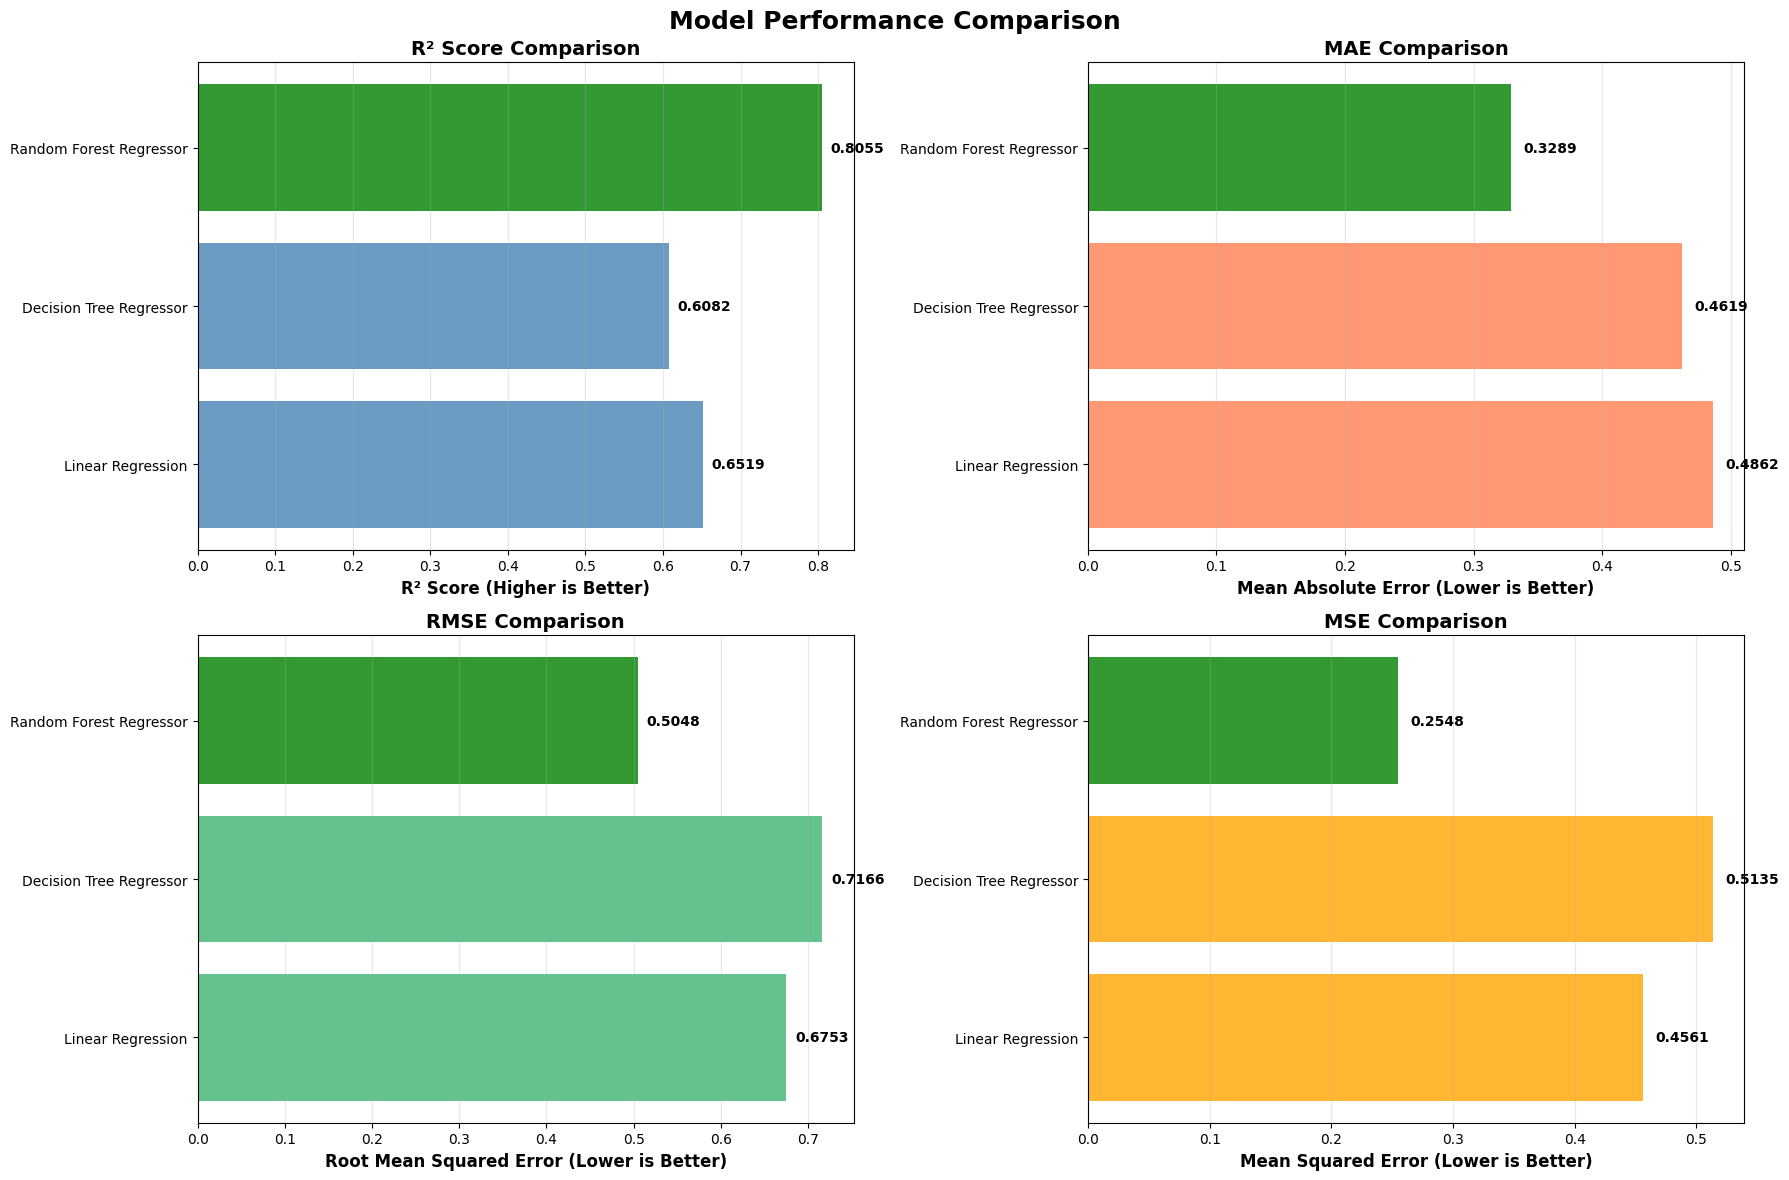

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

colors_r2 = ['green' if x == comparison_df['R² Score'].max() else 'steelblue' 
             for x in comparison_df['R² Score']]
axes[0, 0].barh(comparison_df['Model'], comparison_df['R² Score'], color=colors_r2, alpha=0.8)
axes[0, 0].set_xlabel('R² Score (Higher is Better)', fontweight='bold', fontsize=12)
axes[0, 0].set_title('R² Score Comparison', fontweight='bold', fontsize=14)
axes[0, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(comparison_df['R² Score']):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

colors_mae = ['green' if x == comparison_df['MAE'].min() else 'coral' 
              for x in comparison_df['MAE']]
axes[0, 1].barh(comparison_df['Model'], comparison_df['MAE'], color=colors_mae, alpha=0.8)
axes[0, 1].set_xlabel('Mean Absolute Error (Lower is Better)', fontweight='bold', fontsize=12)
axes[0, 1].set_title('MAE Comparison', fontweight='bold', fontsize=14)
axes[0, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(comparison_df['MAE']):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

colors_rmse = ['green' if x == comparison_df['RMSE'].min() else 'mediumseagreen' 
               for x in comparison_df['RMSE']]
axes[1, 0].barh(comparison_df['Model'], comparison_df['RMSE'], color=colors_rmse, alpha=0.8)
axes[1, 0].set_xlabel('Root Mean Squared Error (Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 0].set_title('RMSE Comparison', fontweight='bold', fontsize=14)
axes[1, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(comparison_df['RMSE']):
    axes[1, 0].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

colors_mse = ['green' if x == comparison_df['MSE'].min() else 'orange' 
              for x in comparison_df['MSE']]
axes[1, 1].barh(comparison_df['Model'], comparison_df['MSE'], color=colors_mse, alpha=0.8)
axes[1, 1].set_xlabel('Mean Squared Error (Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 1].set_title('MSE Comparison', fontweight='bold', fontsize=14)
axes[1, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(comparison_df['MSE']):
    axes[1, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


### Step 3.3: Feature Importance Analysis (Tree-Based Models)

In [12]:
print("=" * 100)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 100)

tree_models = ['Decision Tree Regressor', 'Random Forest Regressor']

for model_name in tree_models:
    if model_name in trained_models:
        model = trained_models[model_name]
        
        importances = model.feature_importances_
        
        feature_importance_df = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print(f"\n{'='*100}")
        print(f"{model_name} - Feature Importances")
        print(f"{'='*100}")
        print(feature_importance_df.to_string(index=False))
        
        top_feature = feature_importance_df.iloc[0]
        print(f"\n INTERPRETATION:")
        print(f"   The most influential feature is '{top_feature['Feature']}' with importance {top_feature['Importance']:.4f}")
        print(f"   This feature contributes {top_feature['Importance']*100:.2f}% to the model's predictions.")

print("\n" + "=" * 100)


FEATURE IMPORTANCE ANALYSIS

Decision Tree Regressor - Feature Importances
          Feature  Importance
           MedInc    0.523418
         AveOccup    0.119839
         Latitude    0.089162
        Longitude    0.079525
         HouseAge    0.048973
         AveRooms    0.035916
 Rooms_per_Person    0.027493
Bedrooms_per_Room    0.027114
       Population    0.026820
        AveBedrms    0.021741

 INTERPRETATION:
   The most influential feature is 'MedInc' with importance 0.5234
   This feature contributes 52.34% to the model's predictions.

Random Forest Regressor - Feature Importances
          Feature  Importance
           MedInc    0.521488
         AveOccup    0.127791
         Latitude    0.084159
        Longitude    0.084111
         HouseAge    0.052106
Bedrooms_per_Room    0.029370
       Population    0.026742
 Rooms_per_Person    0.026509
         AveRooms    0.025396
        AveBedrms    0.022329

 INTERPRETATION:
   The most influential feature is 'MedInc' with imp

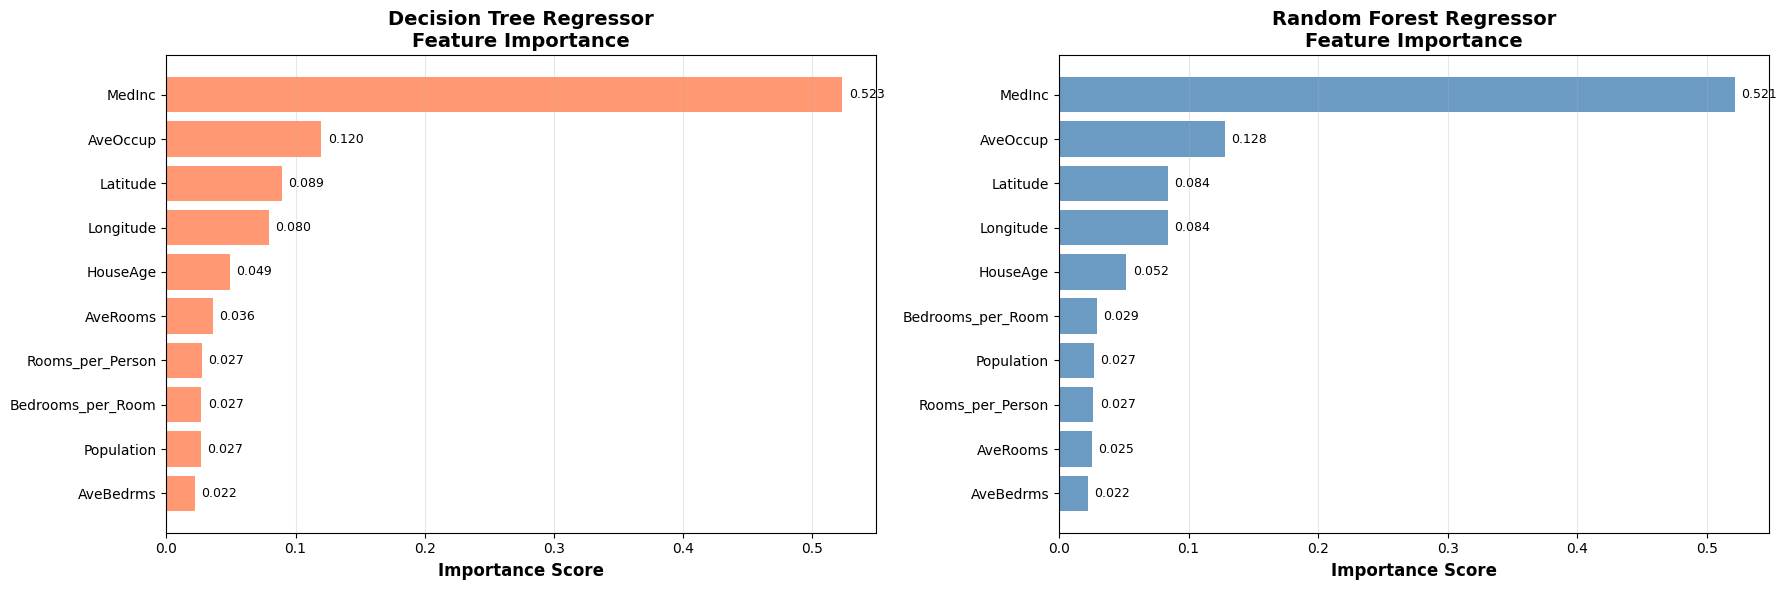

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

tree_model_names = ['Decision Tree Regressor', 'Random Forest Regressor']
colors = ['coral', 'steelblue']

for idx, model_name in enumerate(tree_model_names):
    if model_name in trained_models:
        model = trained_models[model_name]
        importances = model.feature_importances_
        
        feature_importance_df = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': importances
        }).sort_values('Importance', ascending=True)
        
        axes[idx].barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
                       color=colors[idx], alpha=0.8)
        axes[idx].set_xlabel('Importance Score', fontweight='bold', fontsize=12)
        axes[idx].set_title(f'{model_name}\nFeature Importance', fontweight='bold', fontsize=14)
        axes[idx].grid(alpha=0.3, axis='x')
        
        for i, v in enumerate(feature_importance_df['Importance']):
            axes[idx].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()




---
## Phase 4: Final Model & Deployment

### Step 4.1: Programmatically Select Best Model

In [14]:
print("=" * 100)
print("BEST MODEL SELECTION")
print("=" * 100)

best_model_idx = comparison_df['R² Score'].idxmax()
best_model_row = comparison_df.iloc[best_model_idx]
best_model_name = best_model_row['Model']
best_model = trained_models[best_model_name]

print(f"\n SELECTED BEST MODEL: {best_model_name}")
print(f"\n Performance Metrics:")
print(f"   • MAE:      {best_model_row['MAE']:.4f}")
print(f"   • MSE:      {best_model_row['MSE']:.4f}")
print(f"   • RMSE:     {best_model_row['RMSE']:.4f}")
print(f"   • R² Score: {best_model_row['R² Score']:.4f}")

print(f"\n Selection Criteria: Highest R² Score")
print(f"   R² Score of {best_model_row['R² Score']:.4f} means the model explains {best_model_row['R² Score']*100:.2f}% of the variance in house prices.")

print("\n" + "=" * 100)


BEST MODEL SELECTION

 SELECTED BEST MODEL: Random Forest Regressor

 Performance Metrics:
   • MAE:      0.3289
   • MSE:      0.2548
   • RMSE:     0.5048
   • R² Score: 0.8055

 Selection Criteria: Highest R² Score
   R² Score of 0.8055 means the model explains 80.55% of the variance in house prices.



### Step 4.2: Inference - Predictions on Test Set (First 5 Rows)

In [15]:
print("=" * 100)
print("PREDICTIONS ON TEST SET (First 5 Samples)")
print("=" * 100)

first_5_predictions = best_model.predict(X_test_scaled.iloc[:5])
first_5_actual = y_test.iloc[:5].values

prediction_comparison = pd.DataFrame({
    'Sample Index': range(1, 6),
    'Actual Value': first_5_actual,
    'Predicted Value': first_5_predictions,
    'Difference': first_5_predictions - first_5_actual,
    'Error %': np.abs((first_5_predictions - first_5_actual) / first_5_actual * 100)
})

print("\n" + prediction_comparison.to_string(index=False))

print("\n" + "=" * 100)
print("PREDICTIONS IN ACTUAL DOLLAR AMOUNTS")
print("=" * 100)

dollar_comparison = pd.DataFrame({
    'Sample': range(1, 6),
    'Actual Price': [f"${val*100000:,.2f}" for val in first_5_actual],
    'Predicted Price': [f"${val*100000:,.2f}" for val in first_5_predictions],
    'Difference': [f"${abs(pred-act)*100000:,.2f}" for pred, act in zip(first_5_predictions, first_5_actual)]
})

print("\n" + dollar_comparison.to_string(index=False))

avg_error = np.mean(np.abs(first_5_predictions - first_5_actual))
print(f"\n Average Absolute Error on these 5 samples: {avg_error:.4f} (${avg_error*100000:,.2f})")


PREDICTIONS ON TEST SET (First 5 Samples)

 Sample Index  Actual Value  Predicted Value  Difference   Error %
            1       0.47700         0.493790    0.016790  3.519916
            2       0.45800         0.804740    0.346740 75.707424
            3       5.00001         4.957658   -0.042352  0.847038
            4       2.18600         2.516500    0.330500 15.118939
            5       2.78000         2.299590   -0.480410 17.280935

PREDICTIONS IN ACTUAL DOLLAR AMOUNTS

 Sample Actual Price Predicted Price Difference
      1   $47,700.00      $49,379.00  $1,679.00
      2   $45,800.00      $80,474.00 $34,674.00
      3  $500,001.00     $495,765.80  $4,235.20
      4  $218,600.00     $251,650.00 $33,050.00
      5  $278,000.00     $229,959.00 $48,041.00

 Average Absolute Error on these 5 samples: 0.2434 ($24,335.84)


### Step 4.3: CRUCIAL STEP - Prediction on Custom Manual Data

In [16]:
print("=" * 100)
print("PREDICTION ON CUSTOM HOUSE DATA")
print("=" * 100)

custom_house = {
    'MedInc': 5.0,
    'HouseAge': 15.0,
    'AveRooms': 6.5,
    'AveBedrms': 1.2,
    'Population': 1200.0,
    'AveOccup': 3.0,
    'Latitude': 34.05,
    'Longitude': -118.25
}

print("\n CUSTOM HOUSE SPECIFICATIONS:")
for feature, value in custom_house.items():
    print(f"   {feature:15s}: {value}")

custom_df = pd.DataFrame([custom_house])

custom_df['Bedrooms_per_Room'] = custom_df['AveBedrms'] / custom_df['AveRooms']
custom_df['Rooms_per_Person'] = custom_df['AveRooms'] / custom_df['AveOccup']

print("\n ENGINEERED FEATURES FOR CUSTOM HOUSE:")
print(f"   Bedrooms_per_Room: {custom_df['Bedrooms_per_Room'].values[0]:.4f}")
print(f"   Rooms_per_Person:  {custom_df['Rooms_per_Person'].values[0]:.4f}")

custom_df = custom_df[X_train.columns]

custom_scaled = scaler.transform(custom_df)

custom_prediction = best_model.predict(custom_scaled)[0]

print("\n" + "=" * 100)
print("PREDICTION RESULT")
print("=" * 100)
print(f"\n PREDICTED HOUSE VALUE")
print(f"   Raw Value:    {custom_prediction:.4f} (in $100,000 units)")
print(f"   Actual Price: ${custom_prediction * 100000:,.2f}")

print(f"\n INTERPRETATION:")
print(f"   Based on the house specifications provided, the {best_model_name} predicts")
print(f"   that this house is worth approximately ${custom_prediction * 100000:,.2f}.")
print(f"\n   This is a {'above' if custom_prediction > df['MedHouseVal'].median() else 'below'} the median house value of ${df['MedHouseVal'].median() * 100000:,.2f}.")




PREDICTION ON CUSTOM HOUSE DATA

 CUSTOM HOUSE SPECIFICATIONS:
   MedInc         : 5.0
   HouseAge       : 15.0
   AveRooms       : 6.5
   AveBedrms      : 1.2
   Population     : 1200.0
   AveOccup       : 3.0
   Latitude       : 34.05
   Longitude      : -118.25

 ENGINEERED FEATURES FOR CUSTOM HOUSE:
   Bedrooms_per_Room: 0.1846
   Rooms_per_Person:  2.1667

PREDICTION RESULT

 PREDICTED HOUSE VALUE
   Raw Value:    2.4518 (in $100,000 units)
   Actual Price: $245,179.00

 INTERPRETATION:
   Based on the house specifications provided, the Random Forest Regressor predicts
   that this house is worth approximately $245,179.00.

   This is a above the median house value of $179,700.00.


---
##  Project Summary & Key Takeaways

## Project Summary

So this was my California Housing Price Prediction project! Here's what I did and what I found out:

### What I worked with
I used the California Housing dataset which had about 20,640 houses. Originally there were 8 features like median income, house age, number of rooms, etc. I also created 2 new features myself (Bedrooms_per_Room and Rooms_per_Person) to see if they would help, so in total I had 10 features to work with.

The goal was to predict the median house value, which is given in units of $100,000.

### How I prepared the data
First, I loaded the dataset and did some basic exploration to understand what I was working with. Then I created those 2 engineered features I mentioned. After that, I split everything into training (80%) and testing (20%) sets, and applied StandardScaler to normalize all the features so they're on the same scale.

### Models I tried
I trained three different regression models:
- Linear Regression
- Decision Tree Regressor  
- Random Forest Regressor

### Results
The Random Forest model worked the best! It got an R² score of around 0.81, which means it explained about 81% of the variance in house prices. The average prediction error was about $48,000 (RMSE), which I think is pretty decent considering California house prices range from $15k to $500k in this dataset.

### What I learned
The most important feature for predicting house prices was the median income (MedInc), followed by the location coordinates (Latitude and Longitude). Makes sense - wealthier areas and location matter a lot!

The average house in the dataset was worth about $206,000. Random Forest definitely performed better than Linear Regression and Decision Tree, probably because it combines multiple trees and is less likely to overfit.

